In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
ifg_color = '#6A5ACD'
insula_color = '#D4AF37'


reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


In [3]:
# Step 1. Get how many unique subjects across those four dataset

PHONEME_PATH = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'
TIMIT_PATH = '/cwork/ns458/BIDS-1.0_TIMIT/BIDS/'
SENTENCE_PATH = '/cwork/ns458/BIDS-1.4_SentenceRep/BIDS/'
LEXICAL_PATH = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

RECON_DIR = '/cwork/ns458/ECoG_Recon/'

def bids_to_recon_id(bids_subject: str) -> str:
    """Convert BIDS subject ID (e.g. 'D0088') to FreeSurfer/ECoG_Recon ID (e.g. 'D88')."""
    prefix = bids_subject[0]
    num = int(bids_subject[1:])
    return f"{prefix}{num}"

def get_subjects_with_parcellation(bids_root: str, ref: str = 'bipolar') -> list:
    """Get subjects that have parcellation CSV files."""
    parc_dir = Path(bids_root) / 'derivatives' / 'parcellation'
    if not parc_dir.exists():
        return []
    subjects = []
    for sub_dir in sorted(parc_dir.glob('sub-*')):
        csv_files = list((sub_dir / ref).glob('*.csv'))
        if csv_files:
            subjects.append(sub_dir.name.replace('sub-', ''))
    return subjects

# Collect subjects from all datasets
all_subjects = set()
dataset_subjects = {}

for name, path in [('Phoneme', PHONEME_PATH), ('TIMIT', TIMIT_PATH), 
                   ('Sentence', SENTENCE_PATH), ('Lexical', LEXICAL_PATH)]:
    subs = get_subjects_with_parcellation(path)
    dataset_subjects[name] = subs
    all_subjects.update(subs)
    print(f"{name}: {len(subs)} subjects with parcellation")

print(f"\\nTotal unique subjects: {len(all_subjects)}")
print(f"Subjects: {sorted(all_subjects)}")

Phoneme: 49 subjects with parcellation
TIMIT: 29 subjects with parcellation
Sentence: 32 subjects with parcellation
Lexical: 40 subjects with parcellation
\nTotal unique subjects: 73
Subjects: ['D0005', 'D0007', 'D0008', 'D0009', 'D0015', 'D0016', 'D0017', 'D0018', 'D0019', 'D0020', 'D0022', 'D0023', 'D0024', 'D0025', 'D0026', 'D0027', 'D0028', 'D0029', 'D0031', 'D0032', 'D0033', 'D0035', 'D0038', 'D0040', 'D0041', 'D0042', 'D0044', 'D0045', 'D0046', 'D0047', 'D0049', 'D0052', 'D0053', 'D0054', 'D0055', 'D0056', 'D0057', 'D0058', 'D0059', 'D0060', 'D0061', 'D0063', 'D0064', 'D0065', 'D0066', 'D0067', 'D0068', 'D0069', 'D0070', 'D0071', 'D0073', 'D0075', 'D0077', 'D0079', 'D0080', 'D0081', 'D0084', 'D0085', 'D0086', 'D0088', 'D0090', 'D0091', 'D0092', 'D0093', 'D0094', 'D0095', 'D0096', 'D0100', 'D0101', 'D0102', 'D0103', 'D0115', 'D0117']


In [6]:
# Step 2: Get the insula electrodes for a specific subject

def load_parcellation(bids_root: str, subject: str, ref: str = 'bipolar') -> pd.DataFrame:
    """Load parcellation CSV for a subject using BIDSPath."""
    bids_path = BIDSPath(
        root=os.path.join(bids_root, 'derivatives', 'parcellation'),
        subject=subject,
        suffix='aparc2009s',
        datatype=ref,
        processing='10mm',
        extension='.csv',
        check=False
    )
    csv_files = list(bids_path.match())
    if not csv_files:
        return None
    return pd.read_csv(csv_files[0])

def get_insula_electrodes(df: pd.DataFrame) -> pd.DataFrame:
    """Filter electrodes labeled as insula (INS) in the roi column."""
    return df[df['roi'] == 'INS'].copy()

# Test with one subject - pick one that has insula electrodes
TEST_SUBJECT = 'D0094'
TEST_BIDS_ROOT = PHONEME_PATH

df = load_parcellation(TEST_BIDS_ROOT, TEST_SUBJECT)
if df is not None:
    insula_df = get_insula_electrodes(df)
    print(f"Subject {TEST_SUBJECT}: {len(insula_df)} insula electrodes out of {len(df)} total")
    print(f"\\nInsula electrodes:")
    print(insula_df[['name', 'x', 'y', 'z', 'label', 'roi', 'hemi']])

Subject D0094: 9 insula electrodes out of 193 total
\nInsula electrodes:
                name         x         y         z  \
46     D0094_LFAI3-4 -0.032500  0.004333  0.025333   
47     D0094_LFAI4-5 -0.035500  0.005000  0.027000   
62   D0094_LFPI10-11 -0.032000 -0.007500  0.034875   
104   D0094_LPAI9-10 -0.031114 -0.017000  0.036750   
111     D0094_LIA1-2 -0.029437  0.020156  0.015719   
112     D0094_LIA2-3 -0.028313  0.021469  0.019156   
113     D0094_LIA3-4 -0.027187  0.022781  0.022594   
114     D0094_LIA4-5 -0.026062  0.024094  0.026031   
135    D0094_LTAS1-2 -0.042000  0.000833  0.010833   

                            label  roi hemi  
46   ctx_lh_S_circular_insula_sup  INS    L  
47   ctx_lh_S_circular_insula_sup  INS    L  
62   ctx_lh_S_circular_insula_sup  INS    L  
104  ctx_lh_S_circular_insula_sup  INS    L  
111        ctx_lh_G_insular_short  INS    L  
112        ctx_lh_G_insular_short  INS    L  
113        ctx_lh_G_insular_short  INS    L  
114  ctx_lh_S_circ

In [7]:
# Helper function for subject directory
def get_subject_dir(bids_subject: str, recon_dir: str = RECON_DIR) -> str:
    """Get FreeSurfer subject directory path."""
    recon_id = bids_to_recon_id(bids_subject)
    return os.path.join(recon_dir, recon_id)

In [8]:
# Step 4: Batch find all subjects with insula electrodes

def find_subjects_with_insula(bids_roots: list, ref: str = 'bipolar') -> dict:
    """Find all subjects that have insula electrodes across datasets."""
    results = {}
    for bids_root in bids_roots:
        parc_dir = Path(bids_root) / 'derivatives' / 'parcellation'
        if not parc_dir.exists():
            continue
        for sub_dir in sorted(parc_dir.glob('sub-*')):
            subject = sub_dir.name.replace('sub-', '')
            df_temp = load_parcellation(bids_root, subject, ref)
            if df_temp is not None and 'roi' in df_temp.columns:
                insula_df_temp = get_insula_electrodes(df_temp)
                if len(insula_df_temp) > 0:
                    if subject not in results:
                        results[subject] = {
                            'bids_root': bids_root,
                            'n_insula': len(insula_df_temp),
                            'n_total': len(df_temp),
                        }
    return results

# Find all subjects with insula electrodes
bids_roots = [PHONEME_PATH, TIMIT_PATH, SENTENCE_PATH, LEXICAL_PATH]
subjects_with_insula = find_subjects_with_insula(bids_roots)

print(f"Found {len(subjects_with_insula)} subjects with insula electrodes:")
print("-" * 50)
for sub, info in sorted(subjects_with_insula.items()):
    recon_id = bids_to_recon_id(sub)
    recon_exists = os.path.exists(os.path.join(RECON_DIR, recon_id))
    status = "✓" if recon_exists else "✗ (no recon)"
    print(f"  {sub} -> {recon_id}: {info['n_insula']:3d} insula / {info['n_total']:3d} total {status}")

Found 49 subjects with insula electrodes:
--------------------------------------------------
  D0007 -> D7:   4 insula /  89 total ✓
  D0022 -> D22:   2 insula /  83 total ✓
  D0023 -> D23:   2 insula / 109 total ✓
  D0027 -> D27:   2 insula /  88 total ✓
  D0028 -> D28:   5 insula /  70 total ✓
  D0032 -> D32:   5 insula / 108 total ✓
  D0033 -> D33:   6 insula / 222 total ✓
  D0035 -> D35:   4 insula / 112 total ✓
  D0038 -> D38:   2 insula / 111 total ✓
  D0040 -> D40:  13 insula / 174 total ✓
  D0041 -> D41:   1 insula / 232 total ✓
  D0042 -> D42:   4 insula / 144 total ✓
  D0044 -> D44:   8 insula / 160 total ✓
  D0045 -> D45:  11 insula / 104 total ✓
  D0046 -> D46:   2 insula / 145 total ✓
  D0047 -> D47:   4 insula /  47 total ✓
  D0049 -> D49:   8 insula / 177 total ✓
  D0052 -> D52:   4 insula / 136 total ✓
  D0053 -> D53:   4 insula / 132 total ✓
  D0055 -> D55:   7 insula /  94 total ✓
  D0057 -> D57:   1 insula / 133 total ✓
  D0058 -> D58:   5 insula / 226 total ✓
  D005

Subject: D0094
FreeSurfer dir: /cwork/ns458/ECoG_Recon/D94
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-02 19:59:33.499 (10411.324s) [    7F8546971440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x68ea6b0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-02 19:59:33.567 (10411.392s) [    7F8546971440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x68ea6b0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

Insula-labeled electrodes to verify:
------------------------------------------------------------
  D0094_LFAI3-4        | ctx_lh_S_circular_insula_sup            
  D0094_LFAI4-5        | ctx_lh_S_circular_insula_sup            
  D0094_LFPI10-11      | ctx_lh_S_circular_insula_sup            
  D0094_LPAI9-10       | ctx_lh_S_circular_insula_sup            
  D0094_LIA1-2         | ctx_lh_G_insular_short                  
  D0094_LIA2-3         | ctx_lh_G_insular_short                  
  D0094_LIA3-4         | ctx_lh_G_insular_short                  
  D0094_LIA4-5         | ctx_lh_S_circular_insula_sup            
  D0094_LTAS1-2        | ctx_lh_S_circular_insula_inf            


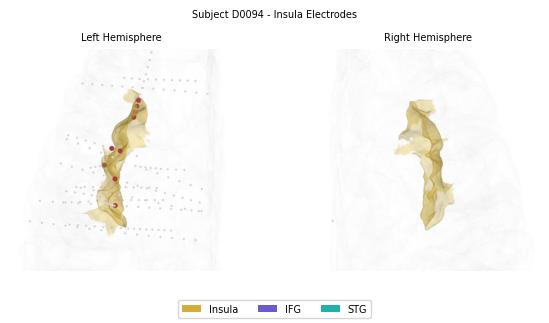

In [23]:
# Step 3: Focused view on insula electrodes with ROI labels highlighted
# Reference: insula_temporal.ipynb Cell 17

import pyvista as pv
from scipy.spatial import cKDTree
from mne.viz import Brain

# Define label patterns for each ROI
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
ifg_patterns = ['G_front_inf-Opercular', 'G_front_inf-Orbital', 'G_front_inf-Triangul']
stg_patterns = ['G_temp_sup-Lateral', 'G_temp_sup-Plan_polar', 'G_temp_sup-Plan_tempo', 'G_temporal_transverse']

def get_insula_center_from_labels(labels, hemi, pial_coords):
    """Calculate the center of insula region from labels."""
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

def plot_insula_focused(
    bids_subject: str,
    df: pd.DataFrame,
    recon_dir: str = RECON_DIR,
    show_all_electrodes: bool = True,
):
    """
    Plot brain with focus on insula region, centered on insula.
    Highlights INS, IFG, STG with different colors using label objects.
    """
    subject_id = bids_to_recon_id(bids_subject)
    subjects_dir = recon_dir
    
    insula_df = get_insula_electrodes(df)
    non_insula_df = df[df['roi'] != 'INS'] if 'roi' in df.columns else df
    
    # Read labels from annotation - use surf_name='pial' since white surface may not exist
    labels = mne.read_labels_from_annot(
        subject=subject_id, parc='aparc.a2009s',
        hemi='both', subjects_dir=subjects_dir,
        surf_name='pial'
    )
    
    # Load pial surfaces for insula center calculation
    lh_pial_coords, _ = mne.read_surface(f"{subjects_dir}/{subject_id}/surf/lh.pial")
    rh_pial_coords, _ = mne.read_surface(f"{subjects_dir}/{subject_id}/surf/rh.pial")
    
    # Get insula centers
    lh_insula_center = get_insula_center_from_labels(labels, 'lh', lh_pial_coords)
    rh_insula_center = get_insula_center_from_labels(labels, 'rh', rh_pial_coords)
    
    # Create brain objects
    lh_brain = Brain(
        subject_id, subjects_dir=subjects_dir, surf="pial",
        hemi="lh", background="white", show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.01, size=(800, 800)
    )
    rh_brain = Brain(
        subject_id, subjects_dir=subjects_dir, surf="pial",
        hemi="rh", background="white", show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.01, size=(800, 800)
    )
    
    # Add labels with different colors for each ROI (using label objects directly)
    for lab in labels:
        # Insula
        if any(pattern in lab.name for pattern in insula_patterns):
            if lab.hemi == 'lh':
                lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)
            elif lab.hemi == 'rh':
                rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)
        # IFG
        elif any(pattern in lab.name for pattern in ifg_patterns):
            if lab.hemi == 'lh':
                lh_brain.add_label(lab, borders=False, color=ifg_color, alpha=0.02)
            elif lab.hemi == 'rh':
                rh_brain.add_label(lab, borders=False, color=ifg_color, alpha=0.02)
        # STG
        elif any(pattern in lab.name for pattern in stg_patterns):
            if lab.hemi == 'lh':
                lh_brain.add_label(lab, borders=False, color=stg_color, alpha=0.02)
            elif lab.hemi == 'rh':
                rh_brain.add_label(lab, borders=False, color=stg_color, alpha=0.02)
    
    # Add electrodes function
    def add_electrodes_to_brain(brain, elec_df, color, point_size=15):
        if len(elec_df) == 0:
            return
        coords = elec_df[['x', 'y', 'z']].values.copy()
        if len(coords) > 0 and np.max(np.abs(coords)) < 1:
            coords = coords * 1000
        for coord in coords:
            cloud = pv.PolyData(coord.reshape(1, 3))
            brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=point_size,
                color=color,
                lighting=False,
            )
    
    # Split electrodes by hemisphere
    lh_insula = insula_df[insula_df['x'] < 0] if len(insula_df) > 0 else pd.DataFrame()
    rh_insula = insula_df[insula_df['x'] > 0] if len(insula_df) > 0 else pd.DataFrame()
    
    if show_all_electrodes:
        lh_non = non_insula_df[non_insula_df['x'] < 0] if len(non_insula_df) > 0 else pd.DataFrame()
        rh_non = non_insula_df[non_insula_df['x'] > 0] if len(non_insula_df) > 0 else pd.DataFrame()
        add_electrodes_to_brain(lh_brain, lh_non, 'lightgray', point_size=8)
        add_electrodes_to_brain(rh_brain, rh_non, 'lightgray', point_size=8)
    
    add_electrodes_to_brain(lh_brain, lh_insula, red, point_size=18)
    add_electrodes_to_brain(rh_brain, rh_insula, red, point_size=18)
    
    # Set view centered on insula
    if lh_insula_center is not None:
        lh_brain.show_view(azimuth=0, elevation=0, distance=180, focalpoint=lh_insula_center)
    else:
        lh_brain.show_view(azimuth=0, elevation=0, distance=200)
    
    if rh_insula_center is not None:
        rh_brain.show_view(azimuth=0, elevation=0, distance=180, focalpoint=rh_insula_center)
    else:
        rh_brain.show_view(azimuth=0, elevation=900, distance=200)
    
    # Print electrode info
    print("Insula-labeled electrodes to verify:")
    print("-" * 60)
    for _, row in insula_df.iterrows():
        print(f"  {row['name']:20s} | {row['label']:40s}")
    
    return lh_brain, rh_brain

# Visualize test subject
TEST_SUBJECT = 'D0094'
subject_dir = get_subject_dir(TEST_SUBJECT)
print(f"Subject: {TEST_SUBJECT}")
print(f"FreeSurfer dir: {subject_dir}")

if df is not None and os.path.exists(subject_dir):
    lh_brain, rh_brain = plot_insula_focused(TEST_SUBJECT, df)
    
    # Screenshot and display
    fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
    
    axes[0].imshow(lh_brain.screenshot(mode="rgb"))
    axes[0].axis("off")
    axes[0].set_title("Left Hemisphere", fontsize=fontsize)
    
    axes[1].imshow(rh_brain.screenshot(mode="rgb"))
    axes[1].axis("off")
    axes[1].set_title("Right Hemisphere", fontsize=fontsize)
    
    lh_brain.close()
    rh_brain.close()
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=insula_color, label='Insula'),
        Patch(facecolor=ifg_color, label='IFG'),
        Patch(facecolor=stg_color, label='STG'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=fontsize)
    
    plt.suptitle(f"Subject {TEST_SUBJECT} - Insula Electrodes", fontsize=fontsize)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

In [22]:
# Step 4: Export 3D interactive HTML visualization
# This creates an interactive HTML file that can be opened in a browser

import pyvista as pv

def export_insula_3d_html(
    bids_subject: str,
    df: pd.DataFrame,
    output_dir: str = '/hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html',
    recon_dir: str = RECON_DIR,
):
    """
    Export 3D interactive visualization of insula electrodes to HTML.
    """
    subject_id = bids_to_recon_id(bids_subject)
    subjects_dir = recon_dir
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    insula_df = get_insula_electrodes(df)
    non_insula_df = df[df['roi'] != 'INS'] if 'roi' in df.columns else df
    
    # Read labels from annotation
    labels = mne.read_labels_from_annot(
        subject=subject_id, parc='aparc.a2009s',
        hemi='both', subjects_dir=subjects_dir,
        surf_name='pial'
    )
    
    # Load pial surfaces
    lh_pial_coords, lh_faces = mne.read_surface(f"{subjects_dir}/{subject_id}/surf/lh.pial")
    rh_pial_coords, rh_faces = mne.read_surface(f"{subjects_dir}/{subject_id}/surf/rh.pial")
    
    # Get insula labels vertices
    lh_insula_vertices = set()
    rh_insula_vertices = set()
    lh_ifg_vertices = set()
    rh_ifg_vertices = set()
    lh_stg_vertices = set()
    rh_stg_vertices = set()
    
    for lab in labels:
        if any(p in lab.name for p in insula_patterns):
            if lab.hemi == 'lh':
                lh_insula_vertices.update(lab.vertices)
            else:
                rh_insula_vertices.update(lab.vertices)
        elif any(p in lab.name for p in ifg_patterns):
            if lab.hemi == 'lh':
                lh_ifg_vertices.update(lab.vertices)
            else:
                rh_ifg_vertices.update(lab.vertices)
        elif any(p in lab.name for p in stg_patterns):
            if lab.hemi == 'lh':
                lh_stg_vertices.update(lab.vertices)
            else:
                rh_stg_vertices.update(lab.vertices)
    
    # Create PyVista plotter
    plotter = pv.Plotter(off_screen=True)
    plotter.set_background('white')
    
    # Helper function to create mesh from FreeSurfer surface
    def create_pv_mesh(coords, faces):
        # FreeSurfer faces are 0-indexed triangles
        # PyVista needs faces in format [3, v0, v1, v2, 3, v0, v1, v2, ...]
        n_faces = len(faces)
        pv_faces = np.zeros((n_faces, 4), dtype=int)
        pv_faces[:, 0] = 3
        pv_faces[:, 1:] = faces
        return pv.PolyData(coords, pv_faces.flatten())
    
    # Create brain meshes
    lh_mesh = create_pv_mesh(lh_pial_coords, lh_faces)
    rh_mesh = create_pv_mesh(rh_pial_coords, rh_faces)
    
    # Create vertex colors for left hemisphere
    lh_colors = np.ones((len(lh_pial_coords), 4)) * [0.9, 0.9, 0.9, 0.01]  # Default: gray, transparent
    for v in lh_insula_vertices:
        if v < len(lh_colors):
            lh_colors[v] = [0.83, 0.69, 0.22, 0.8]  # Insula: gold
    for v in lh_ifg_vertices:
        if v < len(lh_colors):
            lh_colors[v] = [0.42, 0.35, 0.80, 0.1]  # IFG: purple
    for v in lh_stg_vertices:
        if v < len(lh_colors):
            lh_colors[v] = [0.13, 0.70, 0.67, 0.1]  # STG: teal
    
    # Create vertex colors for right hemisphere
    rh_colors = np.ones((len(rh_pial_coords), 4)) * [0.9, 0.9, 0.9, 0.01]
    for v in rh_insula_vertices:
        if v < len(rh_colors):
            rh_colors[v] = [0.83, 0.69, 0.22, 0.8]
    for v in rh_ifg_vertices:
        if v < len(rh_colors):
            rh_colors[v] = [0.42, 0.35, 0.80, 0.1]
    for v in rh_stg_vertices:
        if v < len(rh_colors):
            rh_colors[v] = [0.13, 0.70, 0.67, 0.1]
    
    # Add meshes with vertex colors
    lh_mesh['colors'] = (lh_colors[:, :3] * 255).astype(np.uint8)
    rh_mesh['colors'] = (rh_colors[:, :3] * 255).astype(np.uint8)
    
    plotter.add_mesh(lh_mesh, scalars='colors', rgb=True, opacity=0.2, smooth_shading=True)
    plotter.add_mesh(rh_mesh, scalars='colors', rgb=True, opacity=0.2, smooth_shading=True)
    
    # Add electrodes
    def add_electrodes(elec_df, color, size=5, label_prefix=''):
        if len(elec_df) == 0:
            return
        
        coords = elec_df[['x', 'y', 'z']].values.copy()
        if len(coords) > 0 and np.max(np.abs(coords)) < 1:
            coords = coords * 1000
        
        # Add electrode points
        plotter.add_points(coords, color=color, point_size=size, render_points_as_spheres=True)
        
        # Add electrode labels (FIXED: removed opacity parameter)
        for i, (idx, row) in enumerate(elec_df.iterrows()):
            plotter.add_point_labels(
                coords[i:i+1], 
                [row['name']], 
                point_size=size*2, 
                text_color='black', 
                font_size=10,
                shape_color=color
            )
    
    # Add non-insula electrodes (gray, smaller)
    add_electrodes(non_insula_df, 'lightgray', size=0.5)
    
    # Add insula electrodes (red, larger)
    add_electrodes(insula_df, red, size=1)
    
    # Set camera to focus on insula region
    # Calculate insula center for camera focus
    if len(lh_insula_vertices) > 0:
        lh_center = lh_pial_coords[list(lh_insula_vertices)].mean(axis=0)
        plotter.camera.focal_point = lh_center
        plotter.camera.position = [lh_center[0] - 150, lh_center[1], lh_center[2]]
    
    # Export to HTML
    output_path = os.path.join(output_dir, f'{bids_subject}_insula_3d.html')
    plotter.export_html(output_path)
    plotter.close()
    
    print(f"Exported 3D HTML to: {output_path}")
    print(f"Open this file in a web browser to interact with the 3D visualization.")
    
    # Also print electrode info
    print("\nInsula-labeled electrodes:")
    print("-" * 70)
    for _, row in insula_df.iterrows():
        print(f"  {row['name']:20s} | {row['label']:40s} | frac={row.get('fraction', 'N/A')}")
    
    return output_path

# Export for test subject
print(f"Exporting 3D HTML for subject {TEST_SUBJECT}...")
html_path = export_insula_3d_html(TEST_SUBJECT, df)
print(f"\nDone! You can download and open the HTML file in your browser.")

Exporting 3D HTML for subject D0094...
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D94/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-02 19:58:16.457 (10334.282s) [    7F8546971440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x188bf180): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-02 19:58:16.521 (10334.346s) [    7F8546971440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x188bf180): EGL device index: 0 could not be initialized. Trying other devices...


Exported 3D HTML to: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html/D0094_insula_3d.html
Open this file in a web browser to interact with the 3D visualization.

Insula-labeled electrodes:
----------------------------------------------------------------------
  D0094_LFAI3-4        | ctx_lh_S_circular_insula_sup             | frac=0.1899736147757255
  D0094_LFAI4-5        | ctx_lh_S_circular_insula_sup             | frac=0.198848644758935
  D0094_LFPI10-11      | ctx_lh_S_circular_insula_sup             | frac=0.1592708083473255
  D0094_LPAI9-10       | ctx_lh_S_circular_insula_sup             | frac=0.138882225953466
  D0094_LIA1-2         | ctx_lh_G_insular_short                   | frac=0.2612137203166227
  D0094_LIA2-3         | ctx_lh_G_insular_short                   | frac=0.1902134804509474
  D0094_LIA3-4         | ctx_lh_G_insular_short                   | frac=0.1062604941232909
  D0094_LIA4-5         | ctx_lh_S_circular_insula_sup             | frac=0.1218517630127128


In [13]:
# Step 5: Generate HTML visualizations for ALL subjects with insula electrodes
# This will create an interactive 3D HTML file for each subject

def generate_all_subject_htmls(subjects_dict: dict, output_dir: str = '/hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all'):
    """
    Generate 3D HTML visualizations for all subjects with insula electrodes.
    
    Parameters:
    -----------
    subjects_dict : dict
        Dictionary with subject info from find_subjects_with_insula()
    output_dir : str
        Directory to save all HTML files
    """
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Generating HTML files for {len(subjects_dict)} subjects...")
    print("=" * 80)
    
    successful = []
    failed = []
    
    for i, (subject, info) in enumerate(sorted(subjects_dict.items())):
        print(f"\n[{i+1}/{len(subjects_dict)}] Processing {subject}...")
        
        try:
            # Load parcellation data
            df = load_parcellation(info['bids_root'], subject)
            
            if df is None:
                print(f"  ❌ Failed to load parcellation for {subject}")
                failed.append(subject)
                continue
            
            # Check if subject has reconstruction
            subject_dir = get_subject_dir(subject)
            if not os.path.exists(subject_dir):
                print(f"  ❌ No reconstruction directory for {subject}")
                failed.append(subject)
                continue
            
            # Generate HTML
            html_path = export_insula_3d_html(
                subject, 
                df, 
                output_dir=output_dir
            )
            
            successful.append(subject)
            print(f"  ✅ Generated: {html_path}")
            
        except Exception as e:
            print(f"  ❌ Error processing {subject}: {str(e)}")
            failed.append(subject)
    
    # Summary
    print("\n" + "=" * 80)
    print("GENERATION SUMMARY:")
    print(f"  ✅ Successful: {len(successful)} subjects")
    print(f"  ❌ Failed: {len(failed)} subjects")
    
    if successful:
        print(f"\nSuccessful subjects: {', '.join(successful)}")
    if failed:
        print(f"\nFailed subjects: {', '.join(failed)}")
    
    print(f"\nAll HTML files saved to: {output_dir}")
    print("You can download these files and open them in a web browser.")
    
    return successful, failed

# Execute the batch generation
successful_subjects, failed_subjects = generate_all_subject_htmls(subjects_with_insula)

# Create a summary HTML index file
def create_index_html(subjects_dict: dict, output_dir: str):
    """Create an index HTML file with links to all subject visualizations."""
    
    index_path = os.path.join(output_dir, 'index.html')
    
    html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Insula Electrode Visualizations - All Subjects</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        h1 {{ color: #333; }}
        .subject-grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(300px, 1fr)); gap: 20px; }}
        .subject-card {{ border: 1px solid #ddd; padding: 15px; border-radius: 8px; }}
        .subject-card h3 {{ margin: 0 0 10px 0; color: #2c5aa0; }}
        .info {{ font-size: 0.9em; color: #666; margin: 5px 0; }}
        .link {{ display: inline-block; margin-top: 10px; padding: 8px 16px; background: #2c5aa0; color: white; text-decoration: none; border-radius: 4px; }}
        .link:hover {{ background: #1e3f73; }}
    </style>
</head>
<body>
    <h1>Insula Electrode Visualizations - All Subjects</h1>
    <p>Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
    <p>Total subjects with insula electrodes: {len(subjects_dict)}</p>
    
    <div class="subject-grid">
"""
    
    for subject, info in sorted(subjects_dict.items()):
        html_content += f"""
        <div class="subject-card">
            <h3>{subject}</h3>
            <div class="info">Insula electrodes: {info['n_insula']}</div>
            <div class="info">Total electrodes: {info['n_total']}</div>
            <div class="info">FreeSurfer ID: {bids_to_recon_id(subject)}</div>
            <a href="{subject}_insula_3d.html" class="link">View 3D Visualization</a>
        </div>
"""
    
    html_content += """
    </div>
</body>
</html>
"""
    
    with open(index_path, 'w') as f:
        f.write(html_content)
    
    print(f"Created index HTML: {index_path}")
    return index_path

# Create index file
index_path = create_index_html(subjects_with_insula, '/hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all')

print(f"\n🎉 All done! You can find all visualizations in the output directory.")
print(f"📁 Directory: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all")
print(f"📄 Index file: {index_path}")

Generating HTML files for 49 subjects...

[1/49] Processing D0007...
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D7/label/lh.aparc.a2009s.annot
   read 73 labels from /cwork/ns458/ECoG_Recon/D7/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 12:42:44.837 ( 533.945s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xe834050): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 12:42:44.912 ( 534.020s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xe834050): EGL device index: 0 could not be initialized. Trying other devices...


Exported 3D HTML to: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0007_insula_3d.html
Open this file in a web browser to interact with the 3D visualization.

Insula-labeled electrodes:
----------------------------------------------------------------------
  D0007_RFG1-2         | ctx_rh_G_insular_short                   | frac=0.0921084192852002
  D0007_RFG3-4         | ctx_rh_S_circular_insula_inf             | frac=0.0760374190453346
  D0007_RFG10-11       | ctx_rh_S_circular_insula_sup             | frac=0.0676421204125689
  D0007_RFG11-12       | ctx_rh_S_circular_insula_inf             | frac=0.0590069561045814
  ✅ Generated: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0007_insula_3d.html

[2/49] Processing D0022...
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D22/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D22/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 12:42:52.427 ( 541.536s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x11ab8be0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 12:42:52.485 ( 541.593s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x11ab8be0): EGL device index: 0 could not be initialized. Trying other devices...


Exported 3D HTML to: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0022_insula_3d.html
Open this file in a web browser to interact with the 3D visualization.

Insula-labeled electrodes:
----------------------------------------------------------------------
  D0022_LPIF3-4        | ctx_lh_S_circular_insula_inf             | frac=0.1655073159030942
  D0022_LPIF4-5        | ctx_lh_S_circular_insula_inf             | frac=0.1947709282801631
  ✅ Generated: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0022_insula_3d.html

[3/49] Processing D0023...
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D23/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D23/label/rh.aparc.a2009s.annot


...

Exported 3D HTML to: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0103_insula_3d.html
Open this file in a web browser to interact with the 3D visualization.

Insula-labeled electrodes:
----------------------------------------------------------------------
  D0103_LTAS1-2        | ctx_lh_S_circular_insula_inf             | frac=0.1633485248260973
  D0103_LTMS1-2        | ctx_lh_S_circular_insula_inf             | frac=0.2828016310865915
  D0103_LTMS2-3        | ctx_lh_S_circular_insula_inf             | frac=0.2736867354281602
  D0103_LAI1-2         | ctx_lh_G_insular_short                   | frac=0.2468217798033101
  D0103_LAI2-3         | ctx_lh_G_insular_short                   | frac=0.2787239146078196
  D0103_LAI3-4         | ctx_lh_G_insular_short                   | frac=0.2988726313264572
  D0103_LAI5-6         | ctx_lh_G_insular_short                   | frac=0.1508755097145598
  D0103_LAI6-7         | ctx_lh_G_insular_short                   | frac=0.11297673302

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 13:00:50.998 (1620.106s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x842f4f10): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 13:00:51.054 (1620.162s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x842f4f10): EGL device index: 0 could not be initialized. Trying other devices...


Exported 3D HTML to: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0115_insula_3d.html
Open this file in a web browser to interact with the 3D visualization.

Insula-labeled electrodes:
----------------------------------------------------------------------
  D0115_LTAS3-4        | ctx_lh_S_circular_insula_inf             | frac=0.2072439433917006
  D0115_LTMS1-2        | ctx_lh_S_circular_insula_inf             | frac=0.1549532261933317
  D0115_LTMS2-3        | ctx_lh_S_circular_insula_inf             | frac=0.1645478532022067
  D0115_LIA6-7         | ctx_lh_S_circular_insula_sup             | frac=0.1674262413048692
  ✅ Generated: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0115_insula_3d.html

[49/49] Processing D0117...
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D117/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D117/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 13:00:58.857 (1627.965s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xaf5cad0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2025-12-31 13:00:58.915 (1628.023s) [    7F55381FE440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xaf5cad0): EGL device index: 0 could not be initialized. Trying other devices...


Exported 3D HTML to: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0117_insula_3d.html
Open this file in a web browser to interact with the 3D visualization.

Insula-labeled electrodes:
----------------------------------------------------------------------
  D0117_RINSM1-2       | ctx_rh_G_Ins_lg_and_S_cent_ins           | frac=0.1319261213720316
  D0117_LSAT3-11       | ctx_lh_G_Ins_lg_and_S_cent_ins           | frac=0.0805948668745502
  ✅ Generated: /hpc/home/ns458/coganlab/nanlinshi/insula/viz/3d_html_all/D0117_insula_3d.html

GENERATION SUMMARY:
  ✅ Successful: 49 subjects
  ❌ Failed: 0 subjects

Successful subjects: D0007, D0022, D0023, D0027, D0028, D0032, D0033, D0035, D0038, D0040, D0041, D0042, D0044, D0045, D0046, D0047, D0049, D0052, D0053, D0055, D0057, D0058, D0059, D0060, D0061, D0063, D0064, D0065, D0067, D0068, D0071, D0075, D0079, D0080, D0084, D0085, D0086, D0088, D0090, D0092, D0093, D0094, D0095, D0096, D0101, D0102, D0103, D0115, D0117

All HTML files 